<a href="https://colab.research.google.com/github/vinnijmrtl/Bismillah/blob/main/ETS%20Pembelajran%20Mesin%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import dan inisialisasi library untuk pipeline deep learning klasifikasi citra (image classification)

In [1]:
# Import Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# System libraries
from pathlib import Path
import os.path
import random
from collections import Counter

# Visualization Libraries
import matplotlib.cm as cm
import cv2
import seaborn as sns
from cycler import cycler
import textwrap

sns.set_style('darkgrid')

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# 2. Pengunduhan dataset dari Kaggle

In [2]:
!kaggle datasets download vencerlanz09/alzheimers-mri-brain-scan-images-augmented

Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/alzheimers-mri-brain-scan-images-augmented
License(s): Attribution 4.0 International (CC BY 4.0)
100% 167M/167M [00:02<00:00, 76.0MB/s]



In [3]:
import os

print(os.listdir())

['.config', 'alzheimers-mri-brain-scan-images-augmented.zip', 'sample_data']


- Unzip dataset

Ekstraksi dataset

In [4]:
!unzip -q alzheimers-mri-brain-scan-images-augmented.zip

- Verifikasi struktur dataset setelah ekstraksi (post-unzip directory check)

In [5]:
print(os.listdir())

['.config', 'alzheimers-mri-brain-scan-images-augmented.zip', 'test_images', 'train_images', 'sample_data']


- Path Dataset

Definisi path dataset

In [6]:
train_dir = "/content/train_images"
test_dir = "/content/test_images"

- Image preprocessing dan data augmentation setup menggunakan ImageDataGenerator

Menyiapkan cara data gambar diproses sebelum masuk ke model deep learning (CNN / MobileNetV2)

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

3. Pembuatan metadata dataset (dataset labeling manual ke DataFrame)

 DataFrame ini digunakan untuk mengubah struktur dataset berbasis folder menjadi format tabular yang berisi path gambar dan labelnya, sehingga lebih mudah untuk dilakukan analisis, preprocessing lanjutan, serta feeding data ke model deep learning.


In [8]:
import os
import pandas as pd

train_dir = "/content/train_images"

filepaths = []
labels = []

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)

    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            filepaths.append(os.path.join(label_path, file))
            labels.append(label)

train_df = pd.DataFrame({
    "Filepath": filepaths,
    "Label": labels
})

train_df.head()

,Filepath,Label
0,/content/train_images/mild_dementia/00003886.jpg,mild_dementia
1,/content/train_images/mild_dementia/00006362.jpg,mild_dementia
2,/content/train_images/mild_dementia/00000566.jpg,mild_dementia
3,/content/train_images/mild_dementia/00007431.jpg,mild_dementia
4,/content/train_images/mild_dementia/00001921.jpg,mild_dementia


In [9]:
print(train_df.head())

                                           Filepath          Label
0  /content/train_images/mild_dementia/00003886.jpg  mild_dementia
1  /content/train_images/mild_dementia/00006362.jpg  mild_dementia
2  /content/train_images/mild_dementia/00000566.jpg  mild_dementia
3  /content/train_images/mild_dementia/00007431.jpg  mild_dementia
4  /content/train_images/mild_dementia/00001921.jpg  mild_dementia


4. EDA (Exploratory Data Analysis)

Grafik ini digunakan untuk menganalisis distribusi jumlah data pada setiap kelas dalam dataset, sehingga dapat diketahui apakah dataset seimbang atau tidak. Informasi ini penting untuk menghindari bias model dalam proses training deep learning.

{'mild_dementia': 10217, 'moderated_dementia': 9678, 'non_demented': 11560, 'very_mild_demented': 10792}


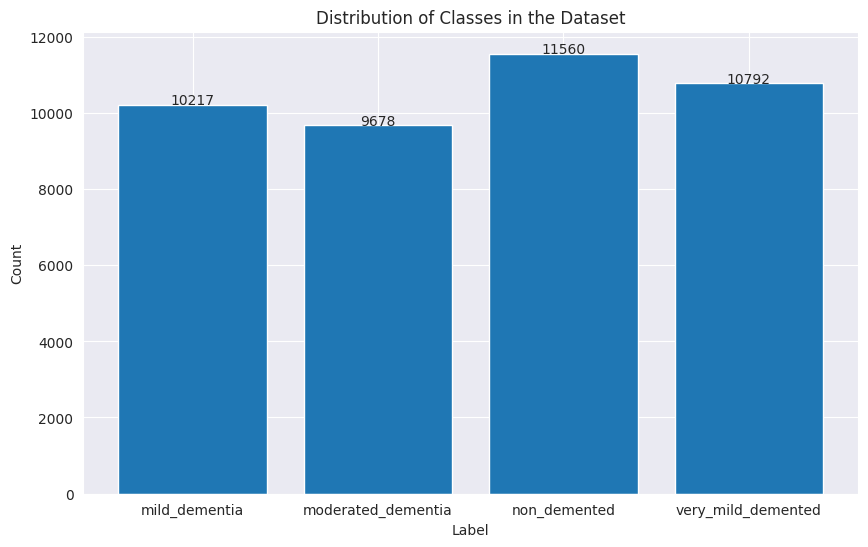

In [10]:
import os
import matplotlib.pyplot as plt

# Path ke folder training
train_dir = "/content/train_images"

# Ambil jumlah gambar per kelas
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

# Tampilkan hasil
print(class_counts)

# Plot bar chart
plt.figure(figsize=(10,6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Distribution of Classes in the Dataset")
plt.xlabel("Label")
plt.ylabel("Count")

# tampilkan angka di atas bar
for i, v in enumerate(class_counts.values()):
    plt.text(i, v, str(v), ha="center")

plt.show()

Hasil tersebut menunjukkan distribusi jumlah data pada setiap kelas dalam dataset MRI Alzheimer. Dari visualisasi ini dapat diketahui apakah dataset seimbang atau tidak, yang sangat penting untuk menghindari bias dalam proses training model deep learning. Analisis distribusi data menunjukkan bahwa jumlah gambar pada setiap kelas tidak sepenuhnya seimbang, sehingga diperlukan perhatian khusus dalam proses pelatihan model untuk menghindari bias terhadap kelas mayoritas.

- Visualisasi sampel acak dataset citra dengan grid subplot

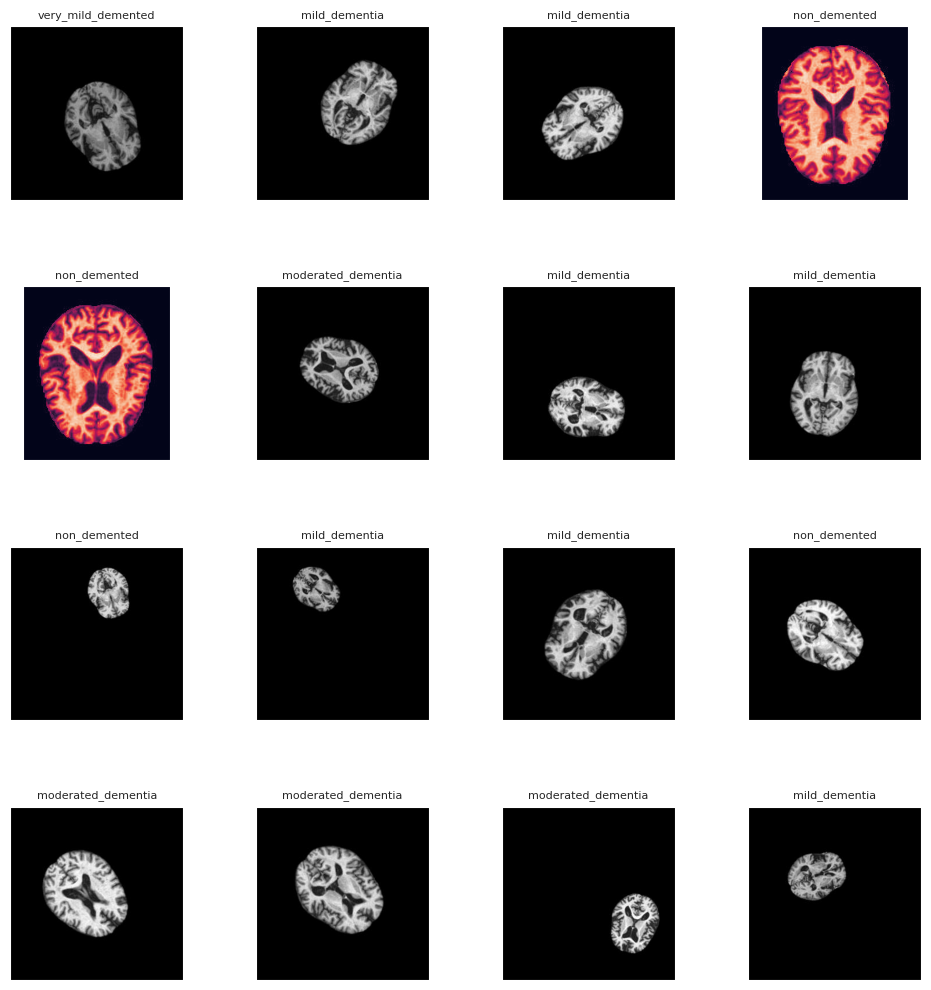

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# Set style
plt.rcParams['axes.titlesize'] = 'small'
plt.rcParams['figure.facecolor'] = 'white'

# Ambil 16 index random
random_index = np.random.randint(
    0,
    len(train_df),
    16
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(10, 10),
    subplot_kw={'xticks': [], 'yticks': []}
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        plt.imread(
            train_df.Filepath[random_index[i]]
        )
    )

    title = train_df.Label[random_index[i]]

    ax.set_title(
        "\n".join(
            textwrap.wrap(title, 20)
        ),
        fontsize=8
    )

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)

plt.show()

Hasil visualisasi menunjukkan bahwa dataset terdiri dari citra MRI otak dengan berbagai tingkat kondisi Alzheimer yang telah terlabel sesuai kelasnya. Sampel acak yang ditampilkan mengonfirmasi bahwa data memiliki variasi visual yang cukup dan label yang konsisten dengan struktur folder dataset.

# - Feature enhancement preprocessing menggunakan Error Level Analysis (ELA) dan fungsi utilitas dataset sampling

Error Level Analysis digunakan untuk memperkuat perbedaan piksel pada citra dengan cara membandingkan gambar asli dan gambar hasil kompresi, sehingga fitur-fitur halus pada citra MRI dapat lebih terlihat dan berpotensi meningkatkan kemampuan model deep learning dalam mengekstraksi pola.

In [12]:
def compute_ela_cv(path, quality):
    temp_filename = 'temp_file_name.jpeg'
    SCALE = 15
    orig_img = cv2.imread(path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

    cv2.imwrite(temp_filename, orig_img, [cv2.IMWRITE_JPEG_QUALITY, quality])

    # read compressed image
    compressed_img = cv2.imread(temp_filename)

    # get absolute difference between img1 and img2 and multiply by scale
    diff = SCALE * cv2.absdiff(orig_img, compressed_img)
    return diff


def convert_to_ela_image(path, quality):
    temp_filename = 'temp_file_name.jpeg'
    ela_filename = 'temp_ela.png'
    image = Image.open(path).convert('RGB')
    image.save(temp_filename, 'JPEG', quality = quality)
    temp_image = Image.open(temp_filename)

    ela_image = ImageChops.difference(image, temp_image)

    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1

    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

    return ela_image


def random_sample(path, extension=None):
    if extension:
        items = Path(path).glob(f'*.{extension}')
    else:
        items = Path(path).glob(f'*')

    items = list(items)

    p = random.choice(items)
    return p.as_posix()

Hasil dari fungsi ini adalah citra MRI yang telah diproses menggunakan Error Level Analysis, yaitu citra dengan kontras yang lebih tinggi dan perbedaan piksel yang diperjelas, sehingga dapat membantu menonjolkan fitur-fitur penting pada gambar sebelum digunakan dalam model deep learning.

- Visualisasi multi-level Error Level Analysis (ELA) pada citra MRI

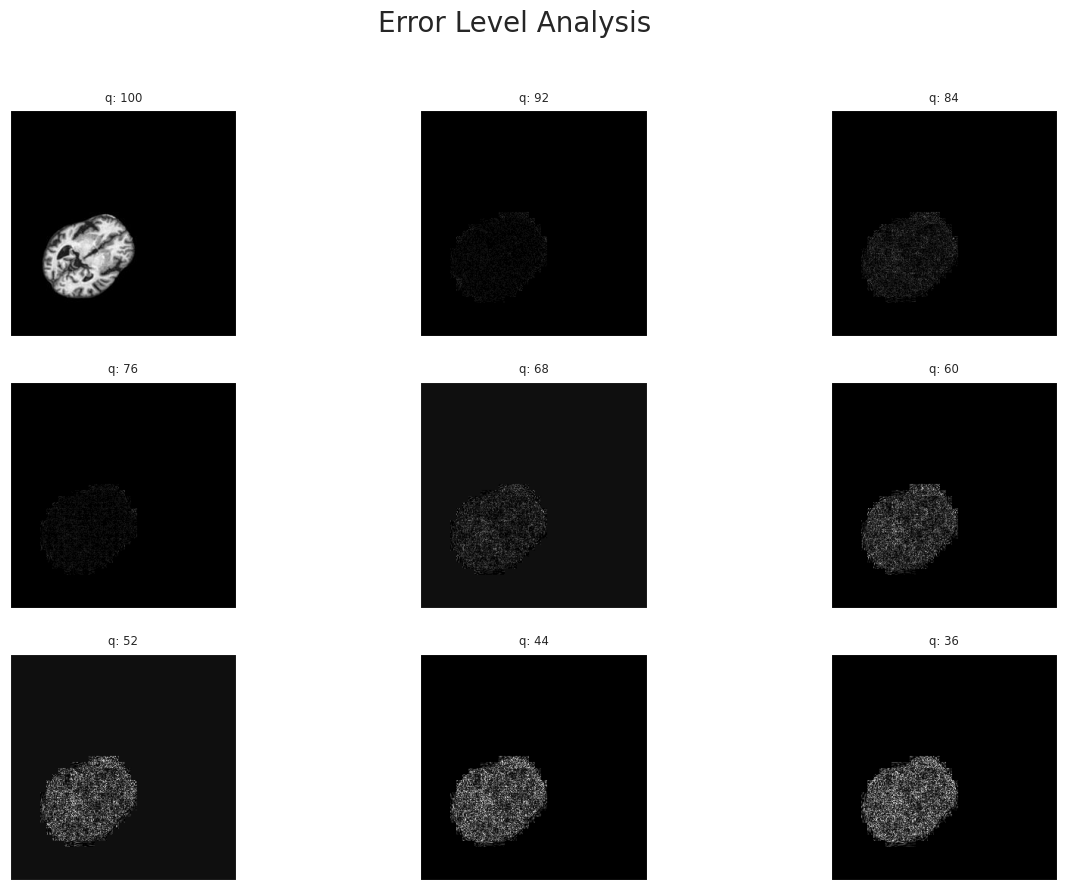

In [13]:
# View random sample from the dataset

p = random_sample('/content/train_images/mild_dementia')

orig = cv2.imread(p)
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB) / 255.0

init_val = 100
columns = 3
rows = 3

fig = plt.figure(figsize=(15, 10))
fig.suptitle('Error Level Analysis', fontsize=20)

for i in range(1, columns*rows + 1):

    quality = init_val - (i-1) * 8

    img = compute_ela_cv(
        path=p,
        quality=quality
    )

    if i == 1:
        img = orig.copy()

    ax = fig.add_subplot(rows, columns, i)

    ax.title.set_text(f'q: {quality}')

    plt.imshow(img)

    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Membandingkan gambar asli dengan beberapa hasil ELA menggunakan berbagai tingkat kualitas kompresi (JPEG quality)

5. EfficientNet preprocessing setup

Pada proses ini dilakukan penyesuaian data gambar agar sesuai dengan format input yang diharapkan oleh model EfficientNetV2.
Model yang digunakan adalah EfficientNetV2 yang merupakan pretrained model, sehingga data input harus disesuaikan dengan distribusi data yang digunakan saat training awal (ImageNet). Oleh karena itu digunakan fungsi preprocess_input agar performa transfer learning lebih optimal.

In [14]:
PROCESSING_MODULE = tf.keras.applications.efficientnet_v2.preprocess_input
train_generator = ImageDataGenerator(
    preprocessing_function=PROCESSING_MODULE,
    validation_split=0.2
)

test_generator = ImageDataGenerator(
    preprocessing_function=PROCESSING_MODULE
)

6. Pembuatan DataFrame dataset testing

DataFrame test_df digunakan untuk menyimpan data testing dalam bentuk struktur tabel yang berisi path gambar dan labelnya, sehingga memudahkan proses evaluasi model deep learning dalam mengukur performa terhadap data yang belum pernah dilihat sebelumnya.

In [15]:
import os
import pandas as pd

test_dir = "/content/test_images"   # SESUAIKAN PATH

filepaths = []
labels = []

for label in os.listdir(test_dir):

    label_path = os.path.join(test_dir, label);

    if os.path.isdir(label_path):

        for file in os.listdir(label_path):

            filepaths.append(
                os.path.join(label_path, file)
            )

            labels.append(label)

test_df = pd.DataFrame({
    "Filepath": filepaths,
    "Label": labels
})

print("Jumlah data test:", len(test_df))
print(test_df["Label"].unique())

Jumlah data test: 1279
['VeryMildDemented' 'NonDemented' 'ModerateDemented' 'MildDemented']


Hasil tersebut menunjukkan bahwa data testing terdiri dari 1279 citra MRI dengan empat kelas yaitu VeryMildDemented, MildDemented, ModerateDemented, dan NonDemented. Data ini digunakan untuk mengevaluasi kemampuan model dalam mengklasifikasikan tingkat penyakit Alzheimer pada data yang belum pernah dilihat sebelumnya.

7. Data generator pipeline menggunakan flow_from_dataframe untuk training, validation, dan testing

Flow_from_dataframe digunakan untuk mengubah dataset berbentuk DataFrame menjadi batch data yang siap diproses oleh model deep learning. Data ini secara otomatis melakukan resize gambar, normalisasi, serta pengkodean label menjadi categorical untuk mendukung proses klasifikasi multi-kelas pada CNN.

In [16]:
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="Filepath",
    y_col="Label",
    target_size=TARGET_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    subset="training"
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="Filepath",
    y_col="Label",
    target_size=TARGET_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    subset="validation"
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="Filepath",
    y_col="Label",
    target_size=TARGET_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 33798 validated image filenames belonging to 4 classes.
Found 8449 validated image filenames belonging to 4 classes.
Found 1279 validated image filenames belonging to 4 classes.


Output tersebut menunjukkan bahwa dataset berhasil dibagi menjadi data training sebanyak 33.798 gambar, validation sebanyak 8.449 gambar, dan testing sebanyak 1.279 gambar. Semua data telah tervalidasi dan terdiri dari empat kelas Alzheimer, sehingga siap digunakan untuk proses training dan evaluasi model deep learning.

8. Inisialisasi pretrained model EfficientNetV2B0 dengan transfer learning (feature extractor)

EfficientNetV2 digunakan sebagai pretrained model karena sudah dilatih pada dataset ImageNet sehingga mampu mengekstrak fitur visual secara umum. Layer model di-freeze agar bobot yang sudah terlatih tidak berubah, sehingga model berfungsi sebagai feature extractor dan hanya classifier bagian atas yang dilatih untuk tugas klasifikasi Alzheimer.

In [17]:
pretrained_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='max'
)

pretrained_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Output tersebut menunjukkan bahwa TensorFlow sedang mengunduh bobot pretrained dari model EfficientNetV2B0 yang telah dilatih pada dataset ImageNet. Bobot ini digunakan sebagai feature extractor dalam metode transfer learning sehingga model tidak perlu dilatih dari awal.

9. Setup training callbacks untuk optimasi dan kontrol proses pelatihan model

Callback digunakan untuk mengoptimalkan proses training model deep learning. ModelCheckpoint menyimpan model terbaik berdasarkan validation accuracy, EarlyStopping menghentikan training secara otomatis ketika model tidak mengalami peningkatan, dan ReduceLROnPlateau menurunkan learning rate secara adaptif ketika loss tidak membaik.

In [18]:
checkpoint_path = "mld_classification_model_checkpoint.weights.h5"

checkpoint_callback = ModelCheckpoint(
    checkpoint_path,
    save_weights_only=True,
    monitor="val_accuracy",
    save_best_only=True
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

10. Implementasi custom F1-score metric menggunakan TensorFlow backend

F1-score digunakan sebagai metrik evaluasi karena dataset kemungkinan tidak seimbang antar kelas, sehingga accuracy saja tidak cukup. F1-score memberikan keseimbangan antara precision dan recall sehingga lebih representatif dalam menilai performa model klasifikasi Alzheimer.

In [19]:
import tensorflow as tf

def f1_score(y_true, y_pred):
    y_pred = tf.round(y_pred)
    y_true = tf.round(y_true)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    f1 = 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())

    return f1

- Setup TensorBoard callback untuk monitoring eksperimen training model

TensorBoard digunakan untuk memonitor proses training model secara visual, seperti perubahan accuracy dan loss pada setiap epoch, sehingga dapat membantu dalam analisis performa model dan mendeteksi overfitting secara lebih mudah.

In [20]:
import tensorflow as tf
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir
    )

    print(f"Saving TensorBoard log files to: {log_dir}")

    return tensorboard_callback

11. Arsitektur model transfer learning + training model deep learning (EfficientNetV2 + custom classifier)

Model yang digunakan adalah transfer learning berbasis EfficientNetV2B0 sebagai feature extractor yang kemudian ditambahkan layer Dense dan Dropout sebagai classifier untuk membedakan 4 kelas Alzheimer. Model dikompilasi menggunakan Adam optimizer dengan learning rate 0.0001 dan dievaluasi menggunakan accuracy serta F1-score, kemudian dilatih dengan data generator serta callback untuk mencegah overfitting dan meningkatkan performa model.

In [22]:
# Existing model structure
inputs = pretrained_model.input
x = Dense(128, activation='relu')(pretrained_model.output)
x = Dropout(0.45)(x)
# x = Dense(256, activation='relu')(x)
# x = Dropout(0.45)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile with custom F1-Score
model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', f1_score]
)

history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=25,
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs", "mld_classification"),
        checkpoint_callback,
        reduce_lr
    ]
)

Saving TensorBoard log files to: training_logs/mld_classification/20260424-214123
Epoch 1/25
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2570s 2s/step - accuracy: 0.5927 - f1_score: 0.5484 - loss: 0.9421 - val_accuracy: 0.0011 - val_f1_score: 0.0000e+00 - val_loss: 2.7994 - learning_rate: 1.0000e-04
Epoch 2/25
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2365s 2s/step - accuracy: 0.6542 - f1_score: 0.6129 - loss: 0.7511 - val_accuracy: 0.0039 - val_f1_score: 0.0000e+00 - val_loss: 2.4609 - learning_rate: 1.0000e-04
Epoch 3/25
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2415s 2s/step - accuracy: 0.6745 - f1_score: 0.6418 - loss: 0.7074 - val_accuracy: 0.0018 - val_f1_score: 0.0000e+00 - val_loss: 2.2575 - learning_rate: 1.0000e-04
Epoch 4/25
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2355s 2s/step - accuracy: 0.6882 - f1_score: 0.6601 - loss: 0.6776 - val_accuracy: 0.0063 - val_f1_score: 0.0000e+00 - val_loss: 1.9606 - learning_rate: 1.0000e-04
Epoch 5/25
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2356s 2s/step - accuracy: 0.7023 - f1_score: 0.6783 

Pada data training, model menunjukkan peningkatan performa yang konsisten. Accuracy meningkat dari sekitar 59% menjadi 65%, F1-score juga meningkat dari 0.54 menjadi 0.61, sedangkan loss menurun dari 0.94 menjadi 0.75. Ini menunjukkan bahwa model mampu belajar pola dari data training dengan baik.

Namun, pada data validation, performa model masih sangat rendah dengan accuracy mendekati nol dan F1-score bernilai nol pada seluruh epoch, yang mengindikasikan adanya masalah generalisasi model terhadap data baru, kemungkinan akibat ketidaksesuaian distribusi data atau preprocessing antara training dan validation

Learning_rate: 1.0000e-04 artinya masih stabil